In [74]:
import pickle as pkl
pkl.dump(model,open('model.pkl','wb'))
pkl.dump(Transformer,open("Transformer.pkl","wb"))
pkl.dump(colText,open('colText.pkl','wb'))
pkl.dump(imputer,open("imputer.pkl","wb"))
pkl.dump(bounds,open("bounds.pkl","wb"))
pkl.dump(colNumber,open('colNumber.pkl','wb'))

In [107]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import xgboost
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score,precision_score,accuracy_score,confusion_matrix,classification_report,recall_score
# from sklearn.
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [108]:
fraud=pd.read_csv("train.csv")
# fraud=fraud.drop(columns=["step","customer","zipcodeOri"])

In [109]:
fraud

,Unnamed: 0,account age,gender,merchant,zipMerchant,category,amount,fraud
0,0,4.0,M,M348934600,28007,transportation,4.55,0
1,1,2.0,M,M348934600,28007,transportation,39.68,0
2,2,4.0,F,M1823072687,28007,transportation,26.89,0
3,3,3.0,M,M348934600,28007,transportation,17.25,0
4,4,5.0,M,M348934600,28007,transportation,35.72,0
...,...,...,...,...,...,...,...,...
594638,594638,3.0,F,M1823072687,28007,transportation,20.53,0
594639,594639,4.0,F,M1823072687,28007,transportation,50.73,0
594640,594640,2.0,F,M349281107,28007,fashion,22.44,0
594641,594641,5.0,M,M1823072687,28007,transportation,14.46,0


In [105]:
fraud.to_csv("train.csv")

In [75]:
# categorical columns
colText=['merchant','gender','category','zipMerchant']

In [76]:
# numerical columns
colNumber=['account age', 'amount']

In [77]:
# handle unnecessary characters, ie space, _ etc
for cols in fraud.columns:
    if fraud[cols].dtype=="object":
        fraud[cols]=fraud[cols].str.replace("'","",regex=False).str.strip()
        fraud[cols]=fraud[cols].str.replace("es_","",regex=False).str.strip()

In [78]:
# convert these columns to string dtype
for catCols in ['account age','gender','merchant','category']:
    fraud[catCols]=fraud[catCols].astype(str)

In [ ]:
fraud

In [79]:
# Convert account age column to numerical col
fraud['account age']=pd.to_numeric(fraud['account age'],errors="coerce")

In [ ]:
# # excluded columns
# columnsToExclude=['customer','zipcodeOri','zipMerchant','step']
# fraud=fraud.drop(columns=columnsToExclude)

In [80]:
# split data
x=fraud.drop(columns=['fraud'])
y=fraud['fraud']
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.3,random_state=35)
xTrain=pd.DataFrame(xTrain)
# xTrain


In [81]:
# Handling null values
imputer=SimpleImputer(strategy="median")


In [82]:
# Remove null values in Xtrain and Xtest dataset
xTrain[colNumber]=imputer.fit_transform(xTrain[colNumber])

In [83]:
xTest[colNumber]=imputer.transform(xTest[colNumber])

In [84]:
# handle outliers
bounds={}
for col in colNumber:
        Q1=xTrain[col].quantile(0.25)
        Q3=xTrain[col].quantile(0.75)
        
        IQR=Q3-Q1
        Upper=Q3+1.5*IQR
        Lower=Q1-1.5*IQR
            
        bounds[col]={"lower":Lower,"upper":Upper}
        xTrain[col]=xTrain[col].clip(lower=Lower,upper=Upper)
        xTest[col]=xTest[col].clip(lower=Lower,upper=Upper)
 

pkl.dump(bounds,open('bounds.pkl','wb'))

In [85]:
xTrain.isnull().sum()

account age    0
gender         0
merchant       0
zipMerchant    0
category       0
amount         0
dtype: int64

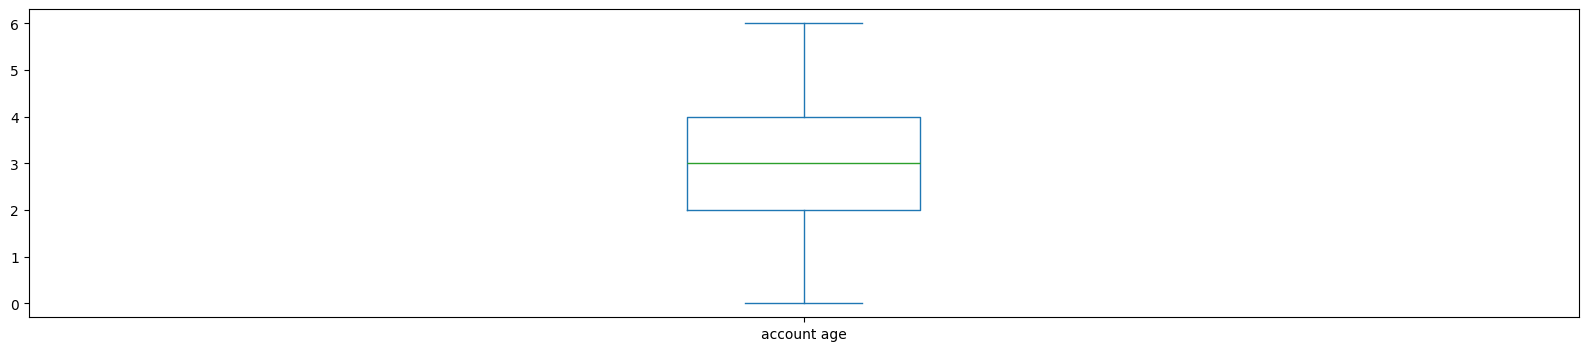

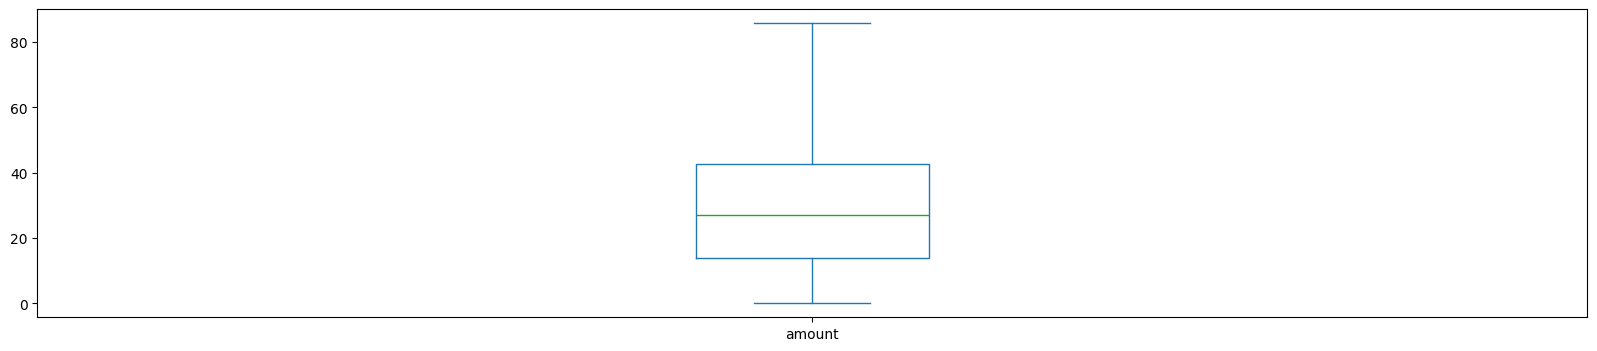

In [86]:
for box in colNumber:
    plt.figure(figsize=(20,4))
    xTrain[box].plot(kind="box")

In [ ]:
# columnsTobeincludedInPipeline=['merchant', 'gender', 'category','account age']

In [87]:
# Feature encoding
pipelineText=Pipeline(

    [("encode",OneHotEncoder(handle_unknown="ignore",sparse_output=False))]
)


Transformer=ColumnTransformer(
    [("encoding",pipelineText,colText)],
    remainder="passthrough"
)

In [88]:
xTrain

,account age,gender,merchant,zipMerchant,category,amount
101208,3.0,M,M1823072687,28007,transportation,14.70
331695,2.0,M,M348934600,28007,transportation,2.07
361567,2.0,M,M1888755466,28007,otherservices,85.79
533284,2.0,F,M1823072687,28007,transportation,26.41
51960,1.0,M,M348934600,28007,transportation,7.01
...,...,...,...,...,...,...
56300,4.0,M,M85975013,28007,food,23.02
179233,2.0,M,M1823072687,28007,transportation,60.77
41911,3.0,M,M348934600,28007,transportation,49.31
378127,2.0,M,M348934600,28007,transportation,34.46


In [104]:
fraud['category'].value_counts()

category
transportation        505119
food                   26254
health                 16133
wellnessandbeauty      15086
fashion                 6454
barsandrestaurants      6373
hyper                   6098
sportsandtoys           4002
tech                    2370
home                    1986
hotelservices           1744
otherservices            912
contents                 885
travel                   728
leisure                  499
Name: count, dtype: int64

In [89]:
# encode .xTrain
xTrain=Transformer.fit_transform(xTrain)

In [ ]:
# fraud

In [90]:
# Encode xTest 
xTest=Transformer.transform(xTest)

In [91]:
model = XGBClassifier(
    n_estimators          = 1000,
    learning_rate         = 0.1,
    max_depth             = 5,
    reg_alpha             = 0.1,
    reg_lambda            = 0.1,
    # scale_pos_weight      = 3.0,  
    # eval_metric           = "logloss",
    # early_stopping_rounds = 50
)

model.fit(
    xTrain, yTrain,
 
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [92]:
# preddiction
predict=model.predict(xTest)

In [65]:
predict

array([0, 0, 1, ..., 0, 0, 0], shape=(178393,))

In [95]:
# extract classification report
report=classification_report(yTest,predict,target_names=model.classes_,output_dict=True)

In [96]:
report

{np.int64(0): {'precision': 0.9964486903836662,
  'recall': 0.9967257581260214,
  'f1-score': 0.9965872049974893,
  'support': 176224.0},
 np.int64(1): {'precision': 0.7278301886792453,
  'recall': 0.7113877362840019,
  'f1-score': 0.7195150384705059,
  'support': 2169.0},
 'accuracy': 0.9932564618566873,
 'macro avg': {'precision': 0.8621394395314558,
  'recall': 0.8540567472050116,
  'f1-score': 0.8580511217339977,
  'support': 178393.0},
 'weighted avg': {'precision': 0.9931826792162052,
  'recall': 0.9932564618566873,
  'f1-score': 0.9932184095335583,
  'support': 178393.0}}

In [97]:
reportFrame=pd.DataFrame(report)

In [98]:
reportFrame.transpose()

,precision,recall,f1-score,support
0,0.996449,0.996726,0.996587,176224.000000
1,0.727830,0.711388,0.719515,2169.000000
accuracy,0.993256,0.993256,0.993256,0.993256
macro avg,0.862139,0.854057,0.858051,178393.000000
weighted avg,0.993183,0.993256,0.993218,178393.000000
